## **IMPORTING THE NECESSARY LIBRARIES.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Reading in the data.**

In [2]:
df = pd.read_excel('./merged_output_cleaned.xlsx')
df.head()

,year,immigrant,type of work,education,both sexes,men,women,gender,earnings,wages_salary,total_income
0,2018,Immigrant,Full-time,Less than high school,0.0,0.0,0.0,Female,4158.148734,3652.452532,21578.401899
1,2018,Immigrant,Full-time,Less than high school,0.0,0.0,0.0,Male,15309.529148,14325.448430,36995.739910
2,2018,Immigrant,Full-time,Less than high school,0.0,0.0,0.0,Female,4158.148734,3652.452532,21578.401899
3,2018,Immigrant,Full-time,Less than high school,0.0,0.0,0.0,Male,15309.529148,14325.448430,36995.739910
4,2018,Immigrant,Full-time,Less than high school,0.0,0.0,0.0,Female,4158.148734,3652.452532,21578.401899


## **Bridging the Gap: Education, Labour, and Wages in Ontario.**

**1. How do average wages vary by education level over time?**

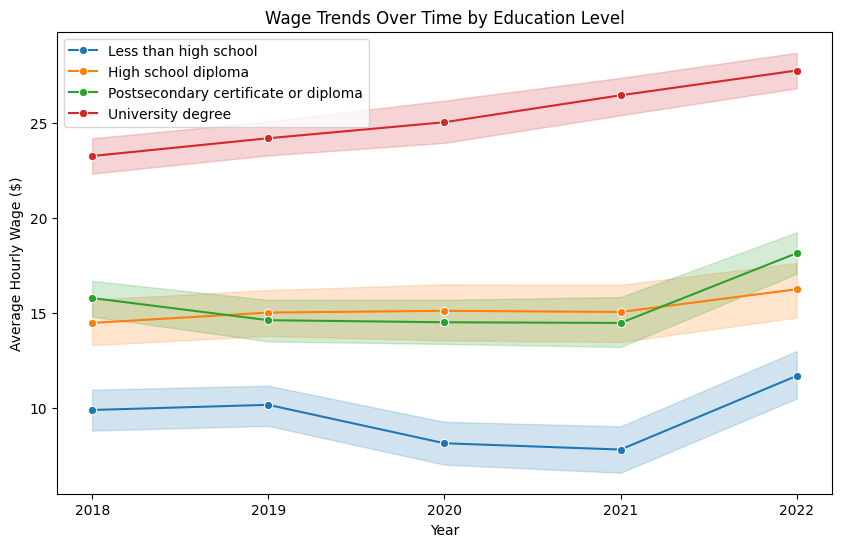

In [3]:
df["year"] = df["year"].astype(int)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=df,
    x="year",
    y="both sexes",
    hue="education",
    marker="o"
)
plt.title("Wage Trends Over Time by Education Level")
plt.ylabel("Average Hourly Wage ($)")
plt.xlabel("Year")
plt.xticks(range(2018, 2023))
plt.legend(loc='upper left')
plt.show()

**Insights:**
- University degree holders consistently earn the highest wages across all years (2018-2022), this shows a clear financial advantage associated with higher education.
- Individuals with less than a high school education earn the lowest wages, with a noticeable decline in 2020 and 2021, which can reasonably be linked to the economic disruptions caused by the COVID-19 pandemic. However, the wages for this education level began to increase in 2022.
- Most other education groups also experienced a decline during 2020-2021, except for university graduates. This could be because higher-educated workers were more protected, likely due to better access to remote and professional employment opportunities.
- By year 2022, all education levels showed recovery from the pandemic shock leading to an increase in wages.
- This confirms that education always increases earning power overtime, and it also shows that the wage gap between low and high education levels remains constant and does not close.

**2a. Do immigrants earn different wages than non-immigrants?**

In [4]:
df.groupby("immigrant")["both sexes"].mean()

,both sexes
immigrant,
Born in Canada (non-immigrant),22.492571
Immigrant,15.376286


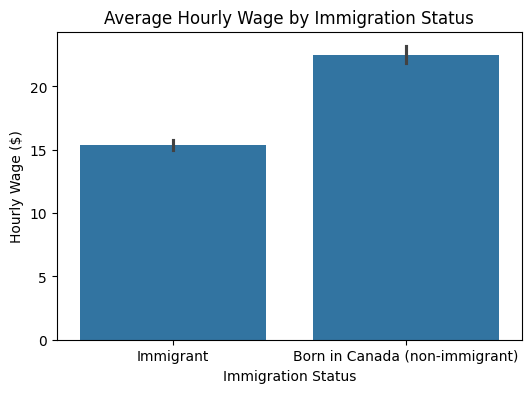

In [5]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="immigrant",
    y="both sexes",
    estimator="mean"
)
plt.title("Average Hourly Wage by Immigration Status")
plt.ylabel("Hourly Wage ($)")
plt.xlabel("Immigration Status")
plt.show()

**Insights:**
- This chart shows a clear wage gap between immigrants and Canadian-Born workers.
- On average, immigrants earn approximately $7 less per hour than Canadian-born workers. However, this chart combines both full-time and part-time workers, meaning that part of the observed gap may be driven by differences in employment type, not hourly wages alone.
- Several factors could contribute to the wage differences, including:

        *   Differences in credential recognition
        *   Language barriers
        *   Limited Canadian Work Experience
        *   Barriers to accessing high paying full-time roles

- Overall, the chart suggests that immigrant status in this dataset is associated with lower average hourly wages in Ontario, though further breakdown by job type is necessary to confirm whether this gap is driven by wage differences, employment quality, or both.

**2b. Is the wage gap still present after seperating for Full-time and Part-time Workers?**

In [6]:
df.groupby(["immigrant", "type of work"])["both sexes"].mean()

immigrant                       type of work
Born in Canada (non-immigrant)  Full-time       27.412571
                                Part-time       17.572571
Immigrant                       Full-time       20.178514
                                Part-time       10.574057
Name: both sexes, dtype: float64

/tmp/ipython-input-3248711237.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


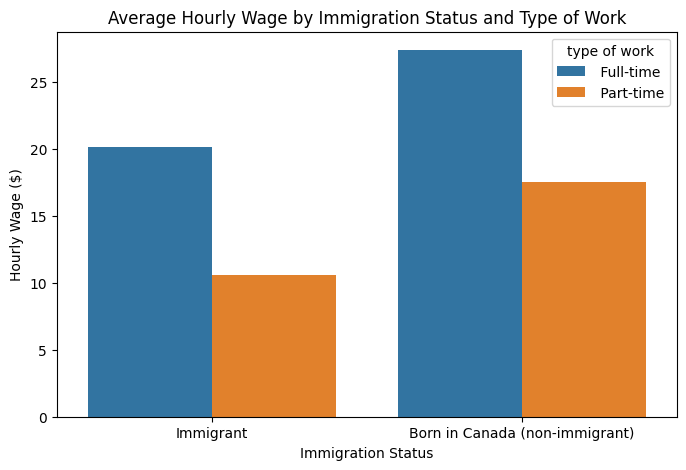

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="immigrant",
    y="both sexes",
    hue="type of work",
    ci=None
)
plt.title("Average Hourly Wage by Immigration Status and Type of Work")
plt.xlabel("Immigration Status")
plt.ylabel("Hourly Wage ($)")
plt.show()

**Insights:**
- Among the full-time workers, immigrants earn about 8dollars/hr less than Canadian-born workers.
- Among the part-time workers, immigrants earn about 6dollars/hr less than Canadian-born workers.
- This confirms that the wage gap persists even when both groups are doing the same type of job, this means employment alone does not fully explain the wage difference.
- This suggest that there's additional labour market barriers which may include:

            *   Credential recognition issues
            *   Limited Canadian experience
            *   Occupational Segregation
            *   Unequal access to high-paying roles.

**3. Does education reduce the immigrant wage gap?**

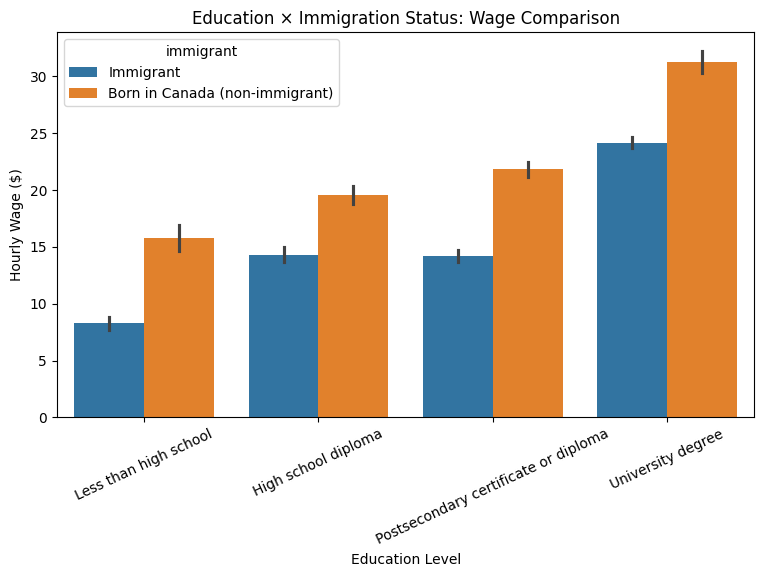

In [8]:
education_order = [
    "Less than high school",
    "High school diploma",
    "Postsecondary certificate or diploma",
    "University degree"
]

plt.figure(figsize=(9,5))
sns.barplot(
    data=df,
    x="education",
    y="both sexes",
    hue="immigrant",
    order=education_order
)
plt.title("Education × Immigration Status: Wage Comparison")
plt.ylabel("Hourly Wage ($)")
plt.xlabel("Education Level")
plt.xticks(rotation=25)
plt.show()


**Insights:**
- At every education level, Canadian-born workers consistently earn higher hourly wages more than Immigrants.
- There is a positive relationship between education and wages for both groups,

    *   Workers with less than high schoool education earns the lowest.
    *   Workers with University degree earns the highest.

- However, the wage gap does not disappear at any education level.
- This shows that education alone is not enough to fully eliminate wage inequality between immigrants and Canadian-born workers.

**4. Is there a gender wage gap?**

/tmp/ipython-input-2174711274.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


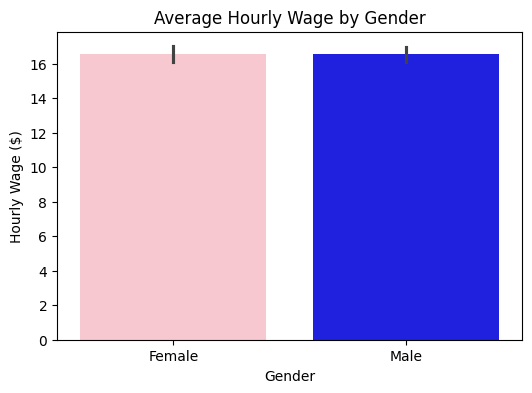

In [9]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="gender",
    y="both sexes",
    estimator="mean",
    palette={"Male":"blue", "Female":"pink"}
)
plt.title("Average Hourly Wage by Gender")
plt.ylabel("Hourly Wage ($)")
plt.xlabel("Gender")
plt.show()

**Insights:**
- This chart shows that male and female workers earn nearly the same average hourly wage in this dataset.
- The wage difference between genders is very small or almost non-existent, suggesting that while education level and immigration status strongly affects wages, gender does not appear to be a major driver of wage inequality here.
- Comparing the wage gaps that was observed by education level and immigration status, gender plays little or no role in explaining overall wage differences here.
- However, the absence of a gender wage gap at this level may be influenced by data aggregation. Gender-based wage differences could still exist within specific industries, job types, or education levels, which are not separately analyzed due to the structure of the public dataset.

**5. Does higher education translate into both higher hourly wages and higher annual income?**

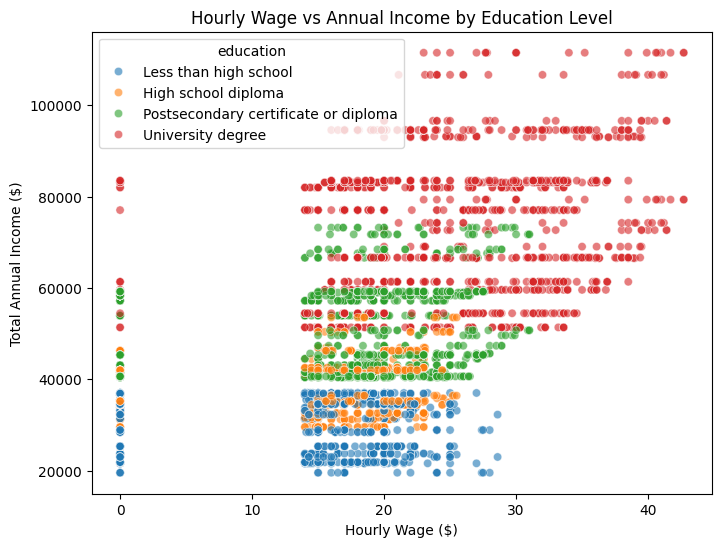

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="both sexes",
    y="total_income",
    hue="education",
    alpha=0.6
)
plt.title("Hourly Wage vs Annual Income by Education Level")
plt.xlabel("Hourly Wage ($)")
plt.ylabel("Total Annual Income ($)")
plt.show()


**Insights:**
- This scatter plot shows a strong positive relationship between hourly wages and total annual income, meaning that as hourly wages increases, total annual income also increases.
- Workers with lower education levels are heavily concentrated in the lower region of the plot, this means they get low wages and low annual incomes.
- Workers with Postsecondary certificate and Univerisity degree shifts towards the upper region of the plot, showing high hourly wages and higher annual income.
- University degree holders shows the highest income range, this confirms that higher education leads to higher earning potential.
- The variability in income increases with higher education levels, shows that while education increases the earnings, it also produces wider differences in income outcomes due to occupational choice, industry placement, and career progression.

**6. How unequal are wages witin each education level?**

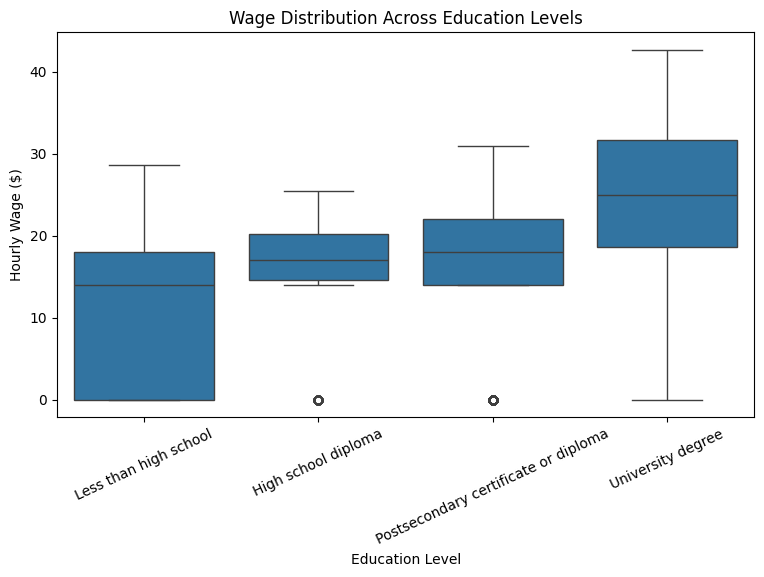

In [11]:
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df,
    x="education",
    y="both sexes",
    order=education_order
)
plt.title("Wage Distribution Across Education Levels")
plt.xlabel("Education Level")
plt.ylabel("Hourly Wage ($)")
plt.xticks(rotation=25)
plt.show()

**Insights:**
- This boxplot shows that median wages increase steadily from left to right, this means:

    *   Individuals with Less than high school education earns the lowest wages.
    *   Those with high school diploma earns more than those without a diploma.
    *   Workers with Postsecondary certificate or diploma earn more that people with High school certificate and less than high school education.
    *   University degree holders have the highest median wage.
- The spread of wages increases with education level:

    *   Lower education groups have narrower wage ranges, this means that most individuals earn within a similar low range.
    *   University degree holders show a much wider spread, indicating greater variation in pay which could be as a result of:
        *   Different professions and Industries
        *   Different seniority and career levels

- The highest wage values (upper whiskers) are seen among university graduates, this confirms that:

    > Higher education provides access to the highest-paying jobs in the labour market.

- The presence of outliers at the lower end for High school diploma and Postsecondary Certificate or diploma groups suggests that:

    *   Some workers still earn very low wages despite holding higher credentials, possibly due to:

      *  Underemployment
      *  Credential recognition Challenges
      *  Entry-level positions


**7. Where is the largest immigrant wage gap by education?**

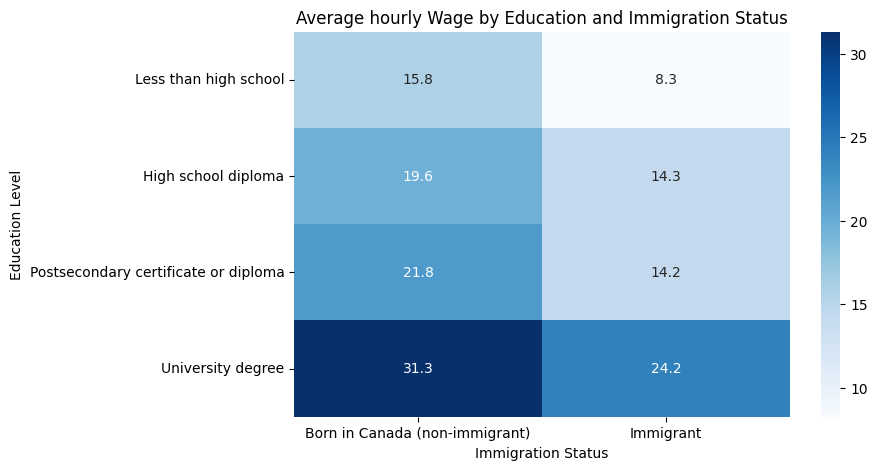

In [12]:
pivot = df.pivot_table(
    values="both sexes",
    index="education",
    columns="immigrant",
    aggfunc="mean"
).reindex(education_order)

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues")
plt.title("Average hourly Wage by Education and Immigration Status")
plt.xlabel("Immigration Status")
plt.ylabel("Education Level")
plt.show()


**Insights:**
- At every education level, Canadian-born workers earn more than immigrants this shows that the immigration wage gaps exists consistently acrosss all levels of education.

- Among individuals with less than high school education:

    *   Canadian-born workers earn about $15.8/hr
    *   Immigrants earn about $8.3/hr
    *   This is nearly a 50% wage difference, showing a very large disadvantage for immigrants at the lowest education level.

- Among high school diploma holders:

    *   Canadian-born workers earn about $19.6/hr
    *   Immigrants earn about $14.3/hr
    *   The wage gap remains constant even when both groups hold the same credential.

- Among postsecondary certificate or diploma holders:

    *  Canadian-born workers earn about $21.8/hr
    *  Immigrants earn about $14.2/hr
    *  This shows that higher education alone does not remove the wage penalty associated with immigrant status.

- Among individuals with university graduates:

    *   Canadian-born workers earn about $31.3/hr
    *   Immigrants earn about $24.2/hr
    *   Even at the highest education level, immigrants earn roughly $7/hr less, showing that education improves wages but does not fully close the immigrant wage gap.

## **Bridging the Gap: Education, Labour, and Wages in Ontario.**
### **Possible Solutions and Key Insights.**

**From the analysis, we found out that:**
- Education strongly increases wages.

    Workers with higher education levels earn significantly more than those with lower credentials.

- A persistent immigrant wage gap exists at every education level

    Even among university graduates, immigrants earn noticeably less than Canadian-born workers.

- The wage gap remains even after separating full-time and part-time workers

    This indicates that the gap is not only due to job type, but also deeper structural factors.

- Gender shows little to no wage difference in this dataset

    Unlike education and immigration status, gender is not a major factor of wage inequality here.

- Higher education also leads to greater income variability

    University graduates experience a wider range of income outcomes due to profession, industry, and career paths.

**Possible factors for the Gap:**

- The data suggests that education alone does not fully explain wage inequality.

- There can be other factors that contribute to the Immigrant wage disadvantage such as:

    - Difficulty with foreign credential recognition

    - Limited Canadian work experience

    - Language and communication barriers

    - Concentration in lower-paying occupations

    - Unequal access to high-paying full-time roles

    - Underemployment, even among highly educated immigrants

**Possible Solutions that could be taken to reduce the Wage Gap.**

1. Improve Credential Recognition Systems

      - Faster and fairer assessment of foreign degrees and certifications.

      - Stronger partnerships between employers and credential evaluation bodies.

2. Expand Canadian Work Experience Programs

      - Paid internship programs for immigrants.

      - Government-subsidized entry-level professional placements.

3. Strengthen Language and Skills Training

      - Industry-specific language training.

      - Professional communication and workplace culture programs.

4. Increase Employer Incentives for Fair Hiring

      - Tax credits for hiring internationally trained workers.

      - Diversity-based recruitment initiatives.

5. Support Career Mobility for Immigrants

      - Mentorship programs.

      - Leadership and career advancement training.

      - Targeted support for transitioning into higher-paying industries.

**Conclusion.**

This analysis confirms that:

1. Education improves wages but does not fully take out inequality.
2. Immigrant workers tend to face a wage disadvantage, even with the same qualifications.
3. To truly bridge the gap between education, labour, and wages in Ontario, policy efforts must go beyond education alone and focus on removing systemic labour market barriers.